# 第四章

## 多层感知机
感知机是一个二分类模型，是最早的AI模型之一。  
它的求解算法等价于使用批量大小为1的梯度下降。  
它不能拟合 XOR 函数。  
单隐藏层 — 单分类

输入 x ∈ R^n

隐藏层 W_1 ∈ R^{m×n}, b_1 ∈ R^m

输出层 w_2 ∈ R^m, b_2 ∈ R

h = σ(W_1x + b_1)

o = w_2^T h + b_2

σ 是按元素的激活函数

多类分类

输入 x ∈ ℝ^n
隐藏层 W₁ ∈ ℝ^m×n, b₁ ∈ ℝ^m
输出层 W₂ ∈ ℝ^m×k, b₂ ∈ ℝ^k

h = σ(W₁x + b₁)
o = W₂^T h + b₂
y = softmax(o)

多隐藏层

$h_{1}=\sigma(W_{1}x+b_{1})$

$h_{2}=\sigma(W_{2}h_{1}+b_{2})$

$h_{3}=\sigma(W_{3}h_{2}+b_{3})$

$o=W_{4}h_{3}+b_{4}$

超参数
- 隐藏层数
- 每层隐藏层的大小

多层感知机使用隐藏层和激活函数来得到非线性模型  
常用激活函数是Sigmoid，Tanh，ReLU  
使用 Softmax 来处理多类分类  
超参数为隐藏层数，和各个隐藏层大小


激活函数：ReLU、sigmoid、tanh  
给定元素$x$，ReLU函数被定义为该元素与$0$的最大值：

**$$\operatorname{ReLU}(x) = \max(x, 0).$$**

ReLU函数通过将相应的活性值设为0，仅保留正元素并丢弃所有负元素。

In [3]:
%matplotlib inline
import torch
from d2l import torch as d2l

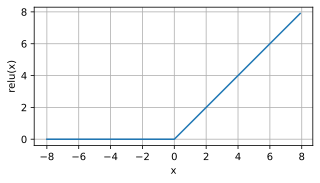

In [4]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

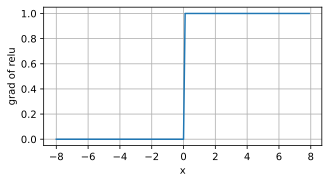

In [5]:
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

sigmoid函数  
将输入变换为区间(0, 1)上的输出。
它将范围（-inf, inf）中的任意输入压缩到区间（0, 1）中的某个值：

**$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$**

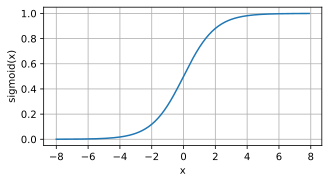

In [6]:
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

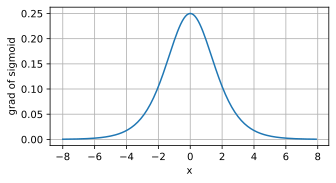

In [7]:
x.grad.data.zero_()# 清除以前的梯度
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

tanh函数  
tanh(双曲正切)函数能将其输入压缩转换到区间(-1, 1)上。
tanh函数的公式如下：

**$$\operatorname{tanh}(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}.$$**

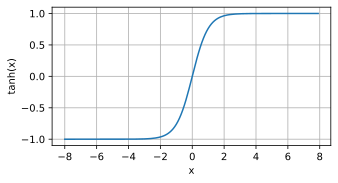

In [8]:
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

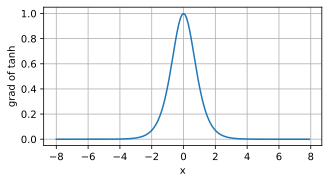

In [9]:
x.grad.data.zero_()# 清除以前的梯度
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

多层感知机的结构：输入层 - 隐藏层 - 输出层

## 多层感知机的从零开始实现

In [10]:
import torch
from torch import nn
from d2l import torch as d2l

In [11]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [12]:
#初始化模型参数
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

In [13]:
#激活函数
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

In [14]:
#模型
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)  # “@”代表矩阵乘法
    return (H@W2 + b2)

In [15]:
#损失函数
loss = nn.CrossEntropyLoss(reduction='none')

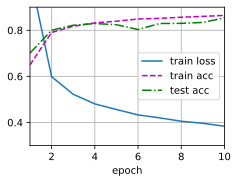

In [16]:
#训练
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

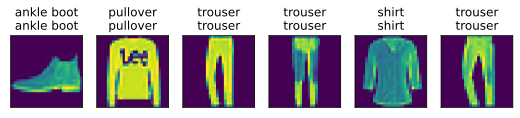

In [17]:
d2l.predict_ch3(net, test_iter)

## 多层感知机的简洁实现

In [19]:
import torch
from torch import nn
from d2l import torch as d2l

In [20]:
#模型
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

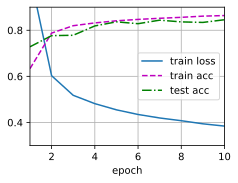

In [21]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

##  模型选择、欠拟合和过拟合  
验证数据集:一个用来评估模型好坏的数据集  
测试数据集:只用一次的数据集。
在没有足够多数据时使用(这是常态)
算法:
·将训练数据分割成K块
Fori= 1,.., K。  
·使用第i块作为验证数据集，其余的作为训练数据集，  
·报告 K个验证集误差的平均  
常用:K=5或10
训练数据集:训练模型参数  
验证数据集:选择模型超参数   
非大数据集上通常使用 k-折交叉验证

欠拟合：模型复杂度不足
过拟合：模型复杂度过高
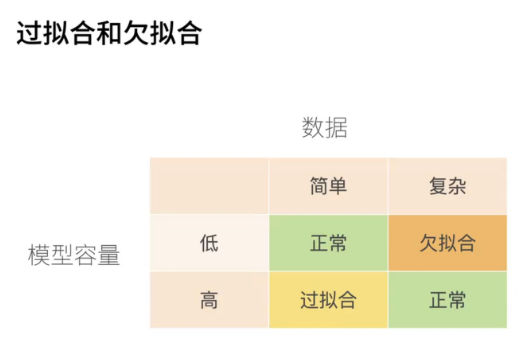

模型容量  
拟合各种函数的能力  
低容量的模型难以拟合训练数据  
高容量的模型可以记住所有的训练数据  
给定一个模型种类，将有两个主要因素：参数的个数和参数值的选择范围  
欠拟合是指模型无法继续减少训练误差。过拟合是指训练误差远小于验证误差。

## 权重衰减

权重衰退通过 L2 正则项使得模型参数不会过大，从而控制模型复杂度  
正则项权重是控制模型复杂度的超参数

In [22]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [23]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [24]:
#从零开始实现
#初始化模型参数
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [25]:
#定义L2范数惩罚
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2


In [26]:
#定义训练代码实现
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.515868186950684


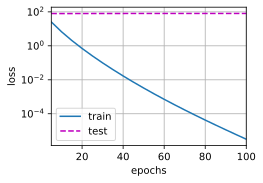

In [27]:
train(lambd=0)

w的L2范数是： 0.3837096691131592


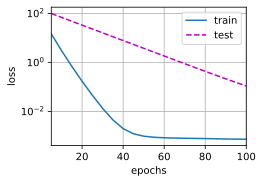

In [28]:
#使用权重衰减
train(lambd=3)

In [29]:
#简洁实现
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 14.556756973266602


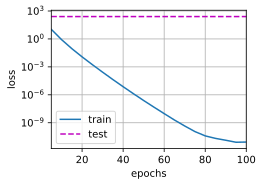

In [30]:
train_concise(0)

w的L2范数： 0.5030871033668518


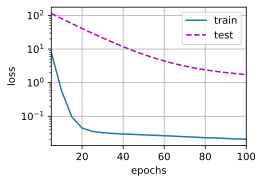

In [31]:
train_concise(3)

## 暂退法（Dropout）

使用丢弃法  
• 通常将丢弃法作用在隐藏全连接层的输出上
$$\begin{aligned}
& \mathbf{h} = \sigma(\mathbf{W_1x} + \mathbf{b_1}) \\
& \mathbf{h'} = \text{dropout}(\mathbf{h}) \\
& \mathbf{o} = \mathbf{W_2h'} + \mathbf{b_2} \\
& \mathbf{y} = \text{softmax}(\mathbf{o})
\end{aligned}$$

丢弃法将一些输出项随机置0来控制模型复杂度  
常作用在多层感知机的隐藏层输出上  
丢弃概率是控制模型复杂度的超参数  
暂退法在前向传播过程中，计算每一内部层的同时丢弃一些神经元。

暂退法可以避免过拟合，它通常与控制权重向量的维数和大小结合使用的。

暂退法将活性值h替换为具有期望值h的随机变量。

暂退法仅在训练期间使用。

In [32]:
#从零开始实现
import torch
from torch import nn
from d2l import torch as d2l


def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [33]:
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  0.,  6.,  8., 10., 12.,  0.],
        [ 0.,  0.,  0., 22.,  0., 26., 28.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [34]:
#定义模型参数
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

In [35]:
#定义模型
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out


net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

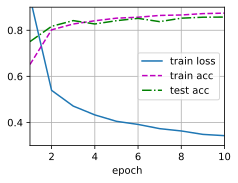

In [36]:
#训练和测试
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [37]:
#简洁实现
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

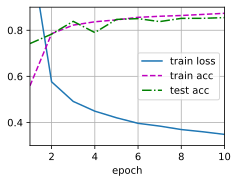

In [38]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## 前向传播反向传播和计算图
前向传播（forward propagation或forward pass） 指的是：按顺序（从输入层到输出层）计算和存储神经网络中每层的结果。

反向传播（backward propagation或backpropagation）指的是计算神经网络参数梯度的方法。该方法根据微积分中的链式规则，按相反的顺序从输出层到输入层遍历网络。 

前向传播在神经网络定义的计算图中按顺序计算和存储中间变量，它的顺序是从输入层到输出层。

反向传播按相反的顺序（从输出层到输入层）计算和存储神经网络的中间变量和参数的梯度。

在训练深度学习模型时，前向传播和反向传播是相互依赖的。

训练比预测需要更多的内存。

## 数值稳定性和模型初始化
梯度值变成 0  
·对 16 位浮点数尤为严重  
训练没有进展  
·不管如何选择学习率  
对于底部层尤为严重  
·仅仅顶部层训练的较好,无法让神经网络更深

值超出值域(infinity)  
·对于 16位浮点数尤为严重  
对学习率敏感  
如果学习率太大 ->大参数值 ->更大的梯度   
如果学习率太小 ->训练无进展  
我们可能需要在训练过程不断调整学习率

当数值过大或者过小时会导致数值问题,常发生在深度模型中，因为其会对n个数累乘  

让梯度值在合理的范围内  
例如 [le-6, 1e3]  
将乘法变加法:ResNet, LSTM  
归一化:梯度归一化，梯度裁剪  
合理的权重初始和激活函数

Xavier 初始
- 难以需要满足 $n_{t-1}\gamma_t=1$ 和 $n_t\gamma_t=1$
- Xavier 使得 $\gamma_t(n_{t-1}+n_t)/2=1$ $\rightarrow$ $\gamma_t=2/(n_{t-1}+n_t)$
- 正态分布 $\mathcal{N}\left(0,\sqrt{2/(n_{t-1}+n_t)}\right)$
- 均匀分布 $\mathcal{U}\left(-\sqrt{6/(n_{t-1}+n_t)},\sqrt{6/(n_{t-1}+n_t)}\right)$
- 分布 $\mathcal{U}[-a,a]$ 和方差是 $a^2/3$
- 适配权重形状变换，特别是 $n_t$


## 环境和分布偏移
协变量偏移、标签偏移、概念偏移

在许多情况下，训练集和测试集并不来自同一个分布。这就是所谓的分布偏移。

真实风险是从真实分布中抽取的所有数据的总体损失的预期。然而，这个数据总体通常是无法获得的。经验风险是训练数据的平均损失，用于近似真实风险。在实践中，我们进行经验风险最小化。

在相应的假设条件下，可以在测试时检测并纠正协变量偏移和标签偏移。在测试时，不考虑这种偏移可能会成为问题。

在某些情况下，环境可能会记住自动操作并以令人惊讶的方式做出响应。在构建模型时，我们必须考虑到这种可能性，并继续监控实时系统，并对我们的模型和环境以意想不到的方式纠缠在一起的可能性持开放态度。


## 实战Kaggle比赛预测房价

In [39]:
#下载和缓存数据集
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

In [40]:
def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [41]:
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():  #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

In [42]:
#访问和读取数据集
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [43]:
DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [44]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv下载..\data\kaggle_house_pred_train.csv...
正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载..\data\kaggle_house_pred_test.csv...


In [45]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [46]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [47]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

In [48]:
#数据预处理
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# 在标准化数据之后，所有均值消失，因此可将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [49]:
# “Dummy_na=True”将“na”（缺失值）视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features.shape

(2919, 331)

In [50]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

In [51]:
#训练
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

In [52]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [53]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 使用Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [54]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

In [55]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

折1，训练log rmse0.170928, 验证log rmse0.157289
折2，训练log rmse0.162285, 验证log rmse0.189620
折3，训练log rmse0.164111, 验证log rmse0.168301
折4，训练log rmse0.167976, 验证log rmse0.154428
折5，训练log rmse0.163246, 验证log rmse0.183092
5-折验证: 平均训练log rmse: 0.165709, 平均验证log rmse: 0.170546


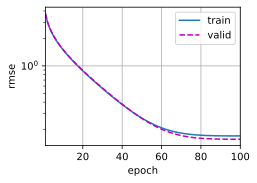

In [56]:
#模型选择
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

In [57]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162434


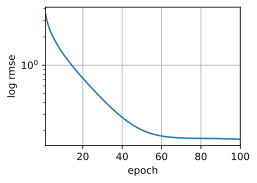

In [58]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

常用的预处理方法：将实值数据重新缩放为零均值和单位方法；用均值替换缺失值。

将类别特征转化为指标特征，可以把这个特征当作一个独热向量来对待。

可以使用K折交叉验证来选择模型并调整超参数。

对数对于相对误差很有用。